In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\KIIT0001\OneDrive\Desktop\Project\05_loan_approval\Data\featured_loan_data.csv")

X = df.drop(columns=["loan_approved", "Loan_Status"])
y = df["loan_approved"]

In [14]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [6]:
X_processed = preprocessor.fit_transform(X)
X_processed.shape

(614, 636)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

In [11]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lr = lr_model.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.78      0.66      0.71        38
           1       0.86      0.92      0.89        85

    accuracy                           0.84       123
   macro avg       0.82      0.79      0.80       123
weighted avg       0.83      0.84      0.83       123



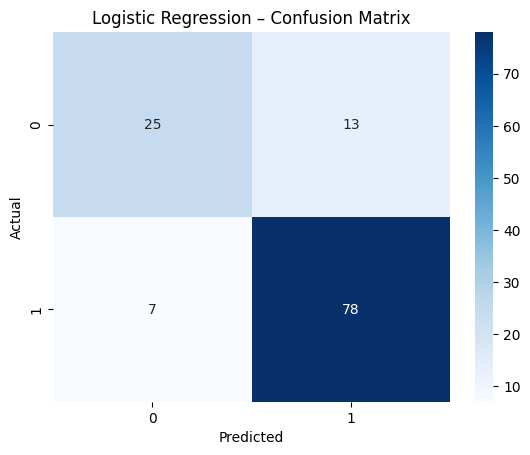

In [13]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression – Confusion Matrix")
plt.show()


IMPROVED MODEL - RANDOM FOREST 

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])


In [17]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.58      0.70        38
           1       0.84      0.96      0.90        85

    accuracy                           0.85       123
   macro avg       0.86      0.77      0.80       123
weighted avg       0.85      0.85      0.84       123



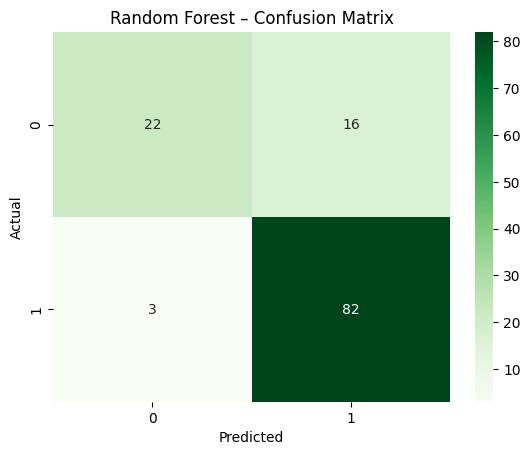

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest – Confusion Matrix")
plt.show()

Random Forest captures complex interactions between income, loan amount, and credit history, improving overall performance compared to Logistic Regression.

EXPLAINABILITY

In [20]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

In [21]:
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = pd.Series(
    importances, index=feature_names
).sort_values(ascending=False)

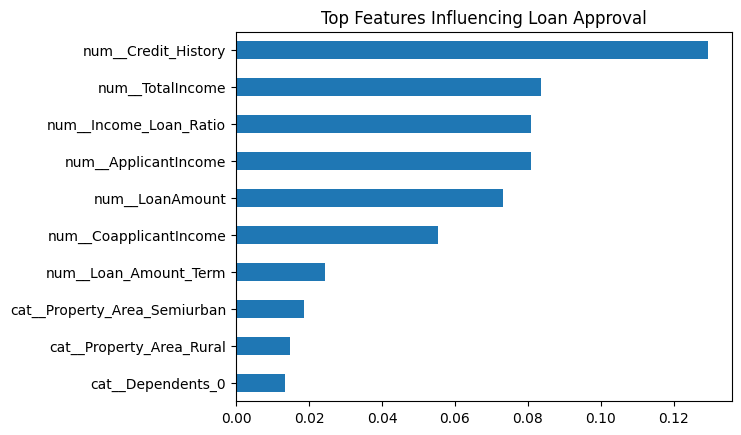

In [22]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="barh")
plt.title("Top Features Influencing Loan Approval")
plt.gca().invert_yaxis()
plt.show()

The model primarily relies on credit history and income-related features to make loan approval decisions.

This makes the predictions transparent and aligned with real-world lending logic.

ANALYSIS:

In [23]:
sample = X_test.iloc[[0]] 

In [24]:
rf_model.predict(sample)
rf_model.predict_proba(sample)

array([[0.835, 0.165]])

In [25]:
modified = sample.copy()
modified["ApplicantIncome"] = modified["ApplicantIncome"] * 1.5

In [26]:
rf_model.predict(modified)
rf_model.predict_proba(modified)

array([[0.815, 0.185]])

Increasing applicant income can shift the model’s prediction toward loan approval, demonstrating sensitivity to financial capacity.

The full preprocessing and modeling pipeline is saved using joblib to ensure reproducibility and prevent data leakage.

In [27]:
import joblib

joblib.dump(rf_model, r"C:\Users\KIIT0001\OneDrive\Desktop\Project\05_loan_approval\Models\loan_approval_model.pkl")

['C:\\Users\\KIIT0001\\OneDrive\\Desktop\\Project\\05_loan_approval\\Models\\loan_approval_model.pkl']

In [29]:
loaded_model = joblib.load(r"C:\Users\KIIT0001\OneDrive\Desktop\Project\05_loan_approval\Models\loan_approval_model.pkl")

loaded_model.predict(X_test[:5])

array([0, 1, 1, 1, 1])

In [31]:
results = X_test.copy()
results["approval_probability"] = rf_model.predict_proba(X_test)[:, 1]
results["predicted_approval"] = rf_model.predict(X_test)

results.to_csv(r"C:\Users\KIIT0001\OneDrive\Desktop\Project\05_loan_approval\Models\loan_predictions.csv", index=False)